In [2]:
import pandas as pd

# Load the datasets from your folder
train_df = pd.read_parquet('KDDTrain.parquet')
test_df = pd.read_parquet('KDDTest.parquet')

print(f"Training data shape: {train_df.shape}")
print(f"Testing data shape: {test_df.shape}")

# Display the first 5 rows of the data
train_df.head()

Training data shape: (125973, 38)
Testing data shape: (22544, 38)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,classnum
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [3]:
# Get the name of the last column (which holds our labels)
label_col = train_df.columns[-1] 
print(f"The label column is named: '{label_col}'\n")

print("Traffic types BEFORE cleaning:")
print(train_df[label_col].value_counts().head(5)) # Show top 5 types

# Function to convert everything to 0 (Normal) or 1 (Attack)
def make_binary(label):
    if label == 'normal':
        return 0
    else:
        return 1

# Apply this function to both our training and testing data
train_df['Label_Binary'] = train_df[label_col].apply(make_binary)
test_df['Label_Binary'] = test_df[label_col].apply(make_binary)

# Drop the old text-based label column
train_df = train_df.drop(columns=[label_col])
test_df = test_df.drop(columns=[label_col])

print("\nTraffic types AFTER cleaning (0 = Normal, 1 = Attack):")
print(train_df['Label_Binary'].value_counts())

The label column is named: 'classnum'

Traffic types BEFORE cleaning:
classnum
21    62557
18    20667
20    19339
19    10284
15     3990
Name: count, dtype: int64

Traffic types AFTER cleaning (0 = Normal, 1 = Attack):
Label_Binary
1    125973
Name: count, dtype: int64


In [7]:
# Reload fresh data to undo our mistake
train_df = pd.read_parquet('KDDTrain.parquet')
test_df = pd.read_parquet('KDDTest.parquet')

# Print the last 5 column names
print("The last 5 columns are:")
print(train_df.columns[-5:])

# Let's peek at the second-to-last column just to be sure
second_to_last = train_df.columns[-2]
print(f"\nValues in '{second_to_last}':")
print(train_df[second_to_last].value_counts().head(5))

The last 5 columns are:
Index(['dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'class', 'classnum'],
      dtype='str')

Values in 'class':
class
normal       67343
neptune      41214
satan         3633
ipsweep       3599
portsweep     2931
Name: count, dtype: int64


In [8]:
# 1. Drop the useless 'classnum' column
train_df = train_df.drop(columns=['classnum'])
test_df = test_df.drop(columns=['classnum'])

# 2. Function to convert 'normal' to 0 and attacks to 1
def make_binary(label):
    if label == 'normal':
        return 0
    else:
        return 1

# 3. Apply the function and create a new 'Label' column
train_df['Label'] = train_df['class'].apply(make_binary)
test_df['Label'] = test_df['class'].apply(make_binary)

# 4. Drop the old text-based 'class' column
train_df = train_df.drop(columns=['class'])
test_df = test_df.drop(columns=['class'])

print("Success! Here is the actual count of Normal (0) vs Attack (1):")
print(train_df['Label'].value_counts())

Success! Here is the actual count of Normal (0) vs Attack (1):
Label
0    67343
1    58630
Name: count, dtype: int64


In [9]:
# The three columns that still have text in them
text_cols = ['protocol_type', 'service', 'flag']

# 1. Convert text into 1s and 0s (One-Hot Encoding)
train_df = pd.get_dummies(train_df, columns=text_cols)
test_df = pd.get_dummies(test_df, columns=text_cols)

# 2. Make sure the training and testing sets have the exact same columns
# (Sometimes the test set is missing a rare protocol that the train set has)
train_df, test_df = train_df.align(test_df, join='inner', axis=1)

# 3. Check our work! Let's make sure everything is numbers now.
print(f"New Training data shape: {train_df.shape}")
print("Data types of the first 5 columns:")
print(train_df.dtypes.head(5))

New Training data shape: (125973, 118)
Data types of the first 5 columns:
duration          uint16
src_bytes          int64
dst_bytes          int64
land               uint8
wrong_fragment     uint8
dtype: object


In [10]:
# 1. Separate Features (X) from Labels (y) for the Training data
X_train = train_df.drop('Label', axis=1)
y_train = train_df['Label']

# 2. Separate Features (X) from Labels (y) for the Testing data
X_test = test_df.drop('Label', axis=1)
y_test = test_df['Label']

print(f"X_train shape (Features): {X_train.shape}")
print(f"y_train shape (Answers):  {y_train.shape}")

X_train shape (Features): (125973, 117)
y_train shape (Answers):  (125973,)


In [12]:
from sklearn.ensemble import RandomForestClassifier

print("Initializing the AI (Random Forest)...")
ids_model = RandomForestClassifier(n_estimators=100, random_state=42)

print("Training the AI on 125,000 packets. Please wait...")
ids_model.fit(X_train, y_train)

print("Training Complete! 🚀")

Initializing the AI (Random Forest)...
Training the AI on 125,000 packets. Please wait...
Training Complete! 🚀


In [10]:
!pip install seaborn matplotlib

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached matplotlib-3.10.9-cp313-cp313-win_amd64.whl.metadata (52 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached matplotlib-3.10.9-cp313-cp313-win_amd64.whl (8.2 MB)



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Asking the AI to predict the test data...

🎯 Final Accuracy Score: 78.49%

Detailed Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.67      0.97      0.80      9711
  Attack (1)       0.97      0.64      0.77     12833

    accuracy                           0.78     22544
   macro avg       0.82      0.81      0.78     22544
weighted avg       0.84      0.78      0.78     22544



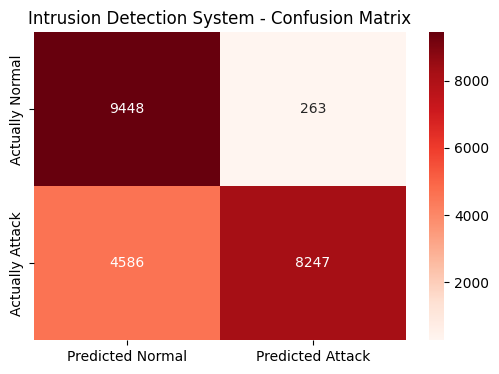

In [10]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Asking the AI to predict the test data...")
predictions = ids_model.predict(X_test)

# 1. Calculate overall accuracy
accuracy = accuracy_score(y_test, predictions)
print(f"\n🎯 Final Accuracy Score: {accuracy * 100:.2f}%\n")

# 2. Print a detailed report (Precision & Recall)
print("Detailed Classification Report:")
print(classification_report(y_test, predictions, target_names=["Normal (0)", "Attack (1)"]))

# 3. Draw a Confusion Matrix Heatmap
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=["Predicted Normal", "Predicted Attack"],
            yticklabels=["Actually Normal", "Actually Attack"])
plt.title("Intrusion Detection System - Confusion Matrix")
plt.show()

In [16]:
import joblib

print("Saving the model...")
# Save the actual AI model
joblib.dump(ids_model, 'ids_model.pkl')

# Save the column names (the web app needs to know exactly what the AI expects)
joblib.dump(X_train.columns.tolist(), 'model_columns.pkl')

# Save 50 rows of our preprocessed test data so we can upload it to our dashboard later!
X_test.head(5).to_csv('sample_traffic.csv', index=False)

print("✅ Model and Sample Data saved successfully!")

Saving the model...
✅ Model and Sample Data saved successfully!


In [12]:
!pip install streamlit

  Using cached jsonschema-4.26.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl.metadata (2.9 kB)
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.1 MB 4.5 MB/s eta 0:00:02
   -------- ------------------------------- 1.8/9.1 MB 4.3 MB/s eta 0:00:02
   ------------ --------------------------- 2.9/9.1 MB 4.7 MB/s eta 0:00:02
   ------------------ --------------------- 4.2/9.1 MB 5.0 MB/s eta 0:00:01
   ----------------------- ---------------- 5.2/9.1 MB 5.0 MB/s eta 0:00:01
   ---------------------------- ----------- 6.6/9.1 MB 5.2 MB/s eta 0:00:01
   --------------------------------- ------ 7.6/9.1 MB 5.2 MB/s eta 0:00:01
   ---------------------------------------  8.9/9.1 MB 5.4 MB/s eta 0:00:01
   ---------------------------------------  8.9/9.1 MB 5.4 MB/s eta 0:00:01
   ---------------------------------------- 9.1/9.1 MB 4.7 MB/s eta 0:00:00
   ---------------


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\hp\AppData\Local\Temp\ipykernel_9632\3736339141.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=raw_train, x='protocol_type', palette='Set2')
C:\Users\hp\AppData\Local\Temp\ipykernel_9632\3736339141.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x_labels, y=y_values, palette='Reds_r')


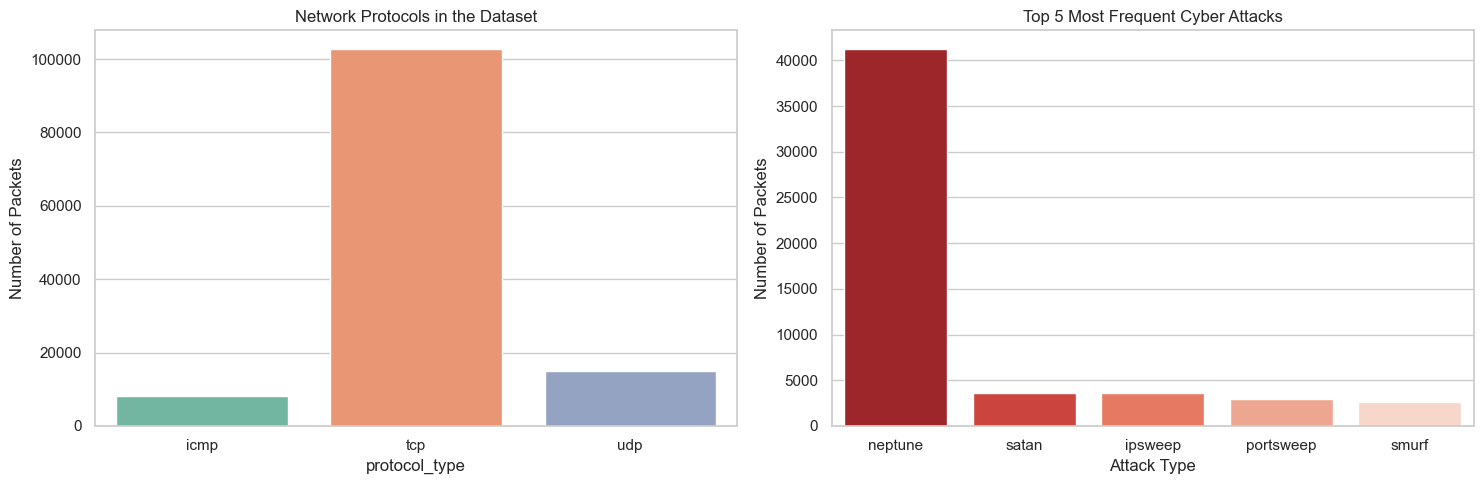

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reload the raw data
raw_train = pd.read_parquet('KDDTrain.parquet')

# Set the style for our charts
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 5))

# --- CHART 1: What protocols are used most? ---
plt.subplot(1, 2, 1)
sns.countplot(data=raw_train, x='protocol_type', palette='Set2')
plt.title('Network Protocols in the Dataset')
plt.ylabel('Number of Packets')

# --- CHART 2: THE FOOLPROOF FIX ---
plt.subplot(1, 2, 2)

# 1. Filter out normal traffic and get the top 5
attacks_only = raw_train[raw_train['class'] != 'normal']
top_5_attacks = attacks_only['class'].value_counts().head(5)

# 2. FORCE them to be plain text strings so the chart forgets the other 35 categories
x_labels = top_5_attacks.index.astype(str).tolist()
y_values = top_5_attacks.values.tolist()

# 3. Plot using the clean text lists
sns.barplot(x=x_labels, y=y_values, palette='Reds_r')
plt.title('Top 5 Most Frequent Cyber Attacks')
plt.ylabel('Number of Packets')
plt.xlabel('Attack Type')

plt.tight_layout()
plt.show()

In [19]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   - -------------------------------------- 2.9/101.7 MB 15.9 MB/s eta 0:00:07
   -- ------------------------------------- 6.6/101.7 MB 16.7 MB/s eta 0:00:06
   ---- ----------------------------------- 10.5/101.7 MB 17.5 MB/s eta 0:00:06
   ----- ---------------------------------- 14.4/101.7 MB 18.0 MB/s eta 0:00:05
   ------ --------------------------------- 15.7/101.7 MB 15.2 MB/s eta 0:00:06
   ------ --------------------------------- 17.6/101.7 MB 14.5 MB/s eta 0:00:06
   ------- -------------------------------- 18.9/101.7 MB 13.1 MB/s eta 0:00:07
   ------- -------------------------------- 19.9/101.7 MB 12.3 MB/s eta 0:00:07
   -------- ------------------------------- 21.0/101.7 MB 11.3 MB/s eta 0:00:08
   -------- ------------------------------- 22.3/101.7 MB 10.8 MB/s eta 0:00:08
   --------- ------------------------------ 23.1/101.7 MB 10.2 MB/s eta 0:00:08
   --------- ------------------------------ 23.9/10


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report

print("Initializing XGBoost...")
# We are tweaking a "Hyperparameter" here: max_depth=6 limits overthinking
xgb_model = xgb.XGBClassifier(n_estimators=100, max_depth=6, random_state=42)

print("Training the XGBoost AI. This might take 15-30 seconds...")
xgb_model.fit(X_train, y_train)

print("Asking XGBoost to predict the test data...")
xgb_predictions = xgb_model.predict(X_test)

# Calculate new accuracy
xgb_accuracy = accuracy_score(y_test, xgb_predictions)
print(f"\n🚀 Old Random Forest Accuracy: 78.49%")
print(f"🔥 New XGBoost Accuracy:      {xgb_accuracy * 100:.2f}%\n")

print("Detailed Report:")
print(classification_report(y_test, xgb_predictions, target_names=["Normal (0)", "Attack (1)"]))

Initializing XGBoost...
Training the XGBoost AI. This might take 15-30 seconds...
Asking XGBoost to predict the test data...

🚀 Old Random Forest Accuracy: 78.49%
🔥 New XGBoost Accuracy:      79.28%

Detailed Report:
              precision    recall  f1-score   support

  Normal (0)       0.68      0.97      0.80      9711
  Attack (1)       0.97      0.66      0.78     12833

    accuracy                           0.79     22544
   macro avg       0.83      0.81      0.79     22544
weighted avg       0.85      0.79      0.79     22544



In [2]:
import pandas as pd

# Load both files
train = pd.read_parquet('KDDTrain.parquet')
test = pd.read_parquet('KDDTest.parquet')

# Get all unique attacks from both files
train_attacks = set(train['class'].unique())
test_attacks = set(test['class'].unique())

# Find the total list and the "Zero-Day" attacks
all_attacks = train_attacks.union(test_attacks)
zero_day_attacks = test_attacks - train_attacks

print(f"Total Unique Classes in Dataset: {len(all_attacks)} (1 'normal' + {len(all_attacks)-1} attacks)")
print("\nAll Attack Types:")
print(sorted(list(all_attacks)))

print(f"\nZero-Day Attacks (Only in Test Set): {len(zero_day_attacks)}")
print(sorted(list(zero_day_attacks)))

Total Unique Classes in Dataset: 40 (1 'normal' + 39 attacks)

All Attack Types:
['apache2', 'back', 'buffer_overflow', 'ftp_write', 'guess_passwd', 'httptunnel', 'imap', 'ipsweep', 'land', 'loadmodule', 'mailbomb', 'mscan', 'multihop', 'named', 'neptune', 'nmap', 'normal', 'perl', 'phf', 'pod', 'portsweep', 'processtable', 'ps', 'rootkit', 'saint', 'satan', 'sendmail', 'smurf', 'snmpgetattack', 'snmpguess', 'spy', 'sqlattack', 'teardrop', 'udpstorm', 'warezclient', 'warezmaster', 'worm', 'xlock', 'xsnoop', 'xterm']

Zero-Day Attacks (Only in Test Set): 17
['apache2', 'httptunnel', 'mailbomb', 'mscan', 'named', 'processtable', 'ps', 'saint', 'sendmail', 'snmpgetattack', 'snmpguess', 'sqlattack', 'udpstorm', 'worm', 'xlock', 'xsnoop', 'xterm']


In [13]:
import pandas as pd

# 1. Reload the raw test data just to get the text names of the attacks
raw_train = pd.read_parquet('KDDTrain.parquet')
raw_test = pd.read_parquet('KDDTest.parquet')

# 2. Identify the Zero-Day attacks (attacks in Test but NOT in Train)
train_attacks = set(raw_train['class'].unique())
test_attacks = set(raw_test['class'].unique())
zero_day_attacks = test_attacks - train_attacks

print(f"Testing the AI on {len(zero_day_attacks)} Zero-Day Attack Types...\n")

# 3. Create a list to store our results
results = []

# 4. Loop through each zero-day attack, test the AI, and record the score
for attack in zero_day_attacks:
    # Find all rows in the test data that are THIS specific attack
    attack_mask = raw_test['class'] == attack
    
    # Grab the exact same rows from our preprocessed Features (X_test)
    attack_X = X_test[attack_mask]
    
    if len(attack_X) > 0:
        # Ask the AI to predict (Will it guess 1 for Attack?)
        # Note: If you used XGBoost earlier, change ids_model to xgb_model here!
        preds = ids_model.predict(attack_X) 
        
        caught = sum(preds == 1)
        total = len(preds)
        
        results.append({
            'Attack Name': attack,
            'Total Packets': total,
            'Caught by AI': caught,
            'Missed': total - caught,
            'Detection Rate (%)': round((caught / total) * 100, 2)
        })

# 5. Display the results as a nice table
results_df = pd.DataFrame(results).sort_values(by='Total Packets', ascending=False)
print(results_df.to_string(index=False))

# Calculate total Zero-Day accuracy
total_zero_day = results_df['Total Packets'].sum()
total_caught = results_df['Caught by AI'].sum()
print(f"\nOverall Zero-Day Detection Rate: {(total_caught / total_zero_day) * 100:.2f}%")

Testing the AI on 17 Zero-Day Attack Types...

  Attack Name  Total Packets  Caught by AI  Missed  Detection Rate (%)
        mscan            996           449     547               45.08
      apache2            737           358     379               48.58
 processtable            685             8     677                1.17
    snmpguess            331             0     331                0.00
        saint            319           313       6               98.12
     mailbomb            293             0     293                0.00
snmpgetattack            178             0     178                0.00
   httptunnel            133             7     126                5.26
        named             17             1      16                5.88
           ps             15             2      13               13.33
     sendmail             14             0      14                0.00
        xterm             13             2      11               15.38
        xlock              9  

In [14]:
from sklearn.ensemble import IsolationForest
import pandas as pd

print("1. Isolating ONLY the 'Normal' traffic from the training data...")
# y_train == 0 means Normal traffic
X_train_normal = X_train[y_train == 0]

print("2. Training the Isolation Forest (Anomaly Detector)...")
# contamination=0.01 means we expect 1% of our "normal" data might actually be sneaky attacks
iso_forest = IsolationForest(contamination=0.01, random_state=42)
iso_forest.fit(X_train_normal)

print("3. Testing the Anomaly Detector on the Zero-Day Attacks...\n")
results_iso = []

# Loop through the zero-day attacks just like before
for attack in zero_day_attacks:
    attack_mask = raw_test['class'] == attack
    attack_X = X_test[attack_mask]
    
    if len(attack_X) > 0:
        # Isolation Forest returns 1 for Normal, and -1 for Anomaly (Attack)
        preds = iso_forest.predict(attack_X) 
        
        # Count how many it flagged as anomalies (-1)
        caught = sum(preds == -1)
        total = len(preds)
        
        results_iso.append({
            'Attack Name': attack,
            'Total Packets': total,
            'Caught by Anomaly AI': caught,
            'Detection Rate (%)': round((caught / total) * 100, 2)
        })

# Display the new results
results_iso_df = pd.DataFrame(results_iso).sort_values(by='Total Packets', ascending=False)
print(results_iso_df.to_string(index=False))

total_zero_day = results_iso_df['Total Packets'].sum()
total_caught = results_iso_df['Caught by Anomaly AI'].sum()
print(f"\n🔥 New Anomaly Detection Rate: {(total_caught / total_zero_day) * 100:.2f}%")

1. Isolating ONLY the 'Normal' traffic from the training data...
2. Training the Isolation Forest (Anomaly Detector)...
3. Testing the Anomaly Detector on the Zero-Day Attacks...

  Attack Name  Total Packets  Caught by Anomaly AI  Detection Rate (%)
        mscan            996                   763               76.61
      apache2            737                   414               56.17
 processtable            685                   251               36.64
    snmpguess            331                     0                0.00
        saint            319                   197               61.76
     mailbomb            293                     0                0.00
snmpgetattack            178                     0                0.00
   httptunnel            133                    18               13.53
        named             17                     0                0.00
           ps             15                     1                6.67
     sendmail             14           